<a href="https://colab.research.google.com/github/khanuja74/khanuja74/blob/main/ECOM_FUR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**E-COMMERCE FURNITURE DATA**

**[A] IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
import warnings
warnings.filterwarnings("ignore")
from IPython.display import Markdown
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

**[B] LOAD DATASET**


In [ ]:
df = pd.read_csv("ecommerce_furniture_dataset_2024.csv")
print(" Data Loaded Successfully!\n")
print("Shape of Dataset:", df.shape)
print("\nPreview of Data:")
print(df.head())


 Data Loaded Successfully!

Shape of Dataset: (2000, 5)

Preview of Data:
                                        productTitle  originalPrice     price  \
0  Dresser For Bedroom With 9 Fabric Drawers Ward...            $30    $46.79   
1  Outdoor Conversation Set 4 Pieces Patio Furnit...           $116   $169.72   
2  Desser For Bedroom With 7 Fabric Drawers Organ...          $78.4    $39.46   
3  Modern Accent Boucle Chair,Upholstered Tufted ...            $89   $111.99   
4  Small Unit Simple Computer Desk Household Wood...         $48.82    $21.37   

   sold        tagText  
0   600  Free shipping  
1     9  Free shipping  
2     7  Free shipping  
3     2  Free shipping  
4     1  Free shipping  


**[C] DATA OVEREVIEW**

In [ ]:
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   productTitle     2000 non-null   object
 1    originalPrice   538 non-null    object
 2   price            2000 non-null   object
 3   sold             2000 non-null   int64 
 4   tagText          1997 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB
None

Missing Values:
productTitle          0
 originalPrice     1462
price                 0
sold                  0
tagText               3
dtype: int64


**[D] DATA CLEANING**

In [ ]:
df.columns = df.columns.str.strip()
df['price'] = df['price'].replace('[$,]', '', regex=True).astype(float)
df['originalPrice'] = df['originalPrice'].replace('[$,]', '', regex=True).astype(float)
df['originalPrice'].fillna(df['originalPrice'].mean(), inplace=True)

df['tagText'] = df['tagText'].apply(lambda x: x if x in ['Free shipping', '+Shipping: $5.09'] else 'others')

print("\n✅ Cleaned Data Sample:")
print(df.head())


✅ Cleaned Data Sample:
                                        productTitle  originalPrice   price  \
0  Dresser For Bedroom With 9 Fabric Drawers Ward...          30.00   46.79   
1  Outdoor Conversation Set 4 Pieces Patio Furnit...         116.00  169.72   
2  Desser For Bedroom With 7 Fabric Drawers Organ...          78.40   39.46   
3  Modern Accent Boucle Chair,Upholstered Tufted ...          89.00  111.99   
4  Small Unit Simple Computer Desk Household Wood...          48.82   21.37   

   sold        tagText  
0   600  Free shipping  
1     9  Free shipping  
2     7  Free shipping  
3     2  Free shipping  
4     1  Free shipping  


**[E] EXPLORATORY DATA ANALYSIS**

**PRICE DISTRIBUTION OF FURNITURE**

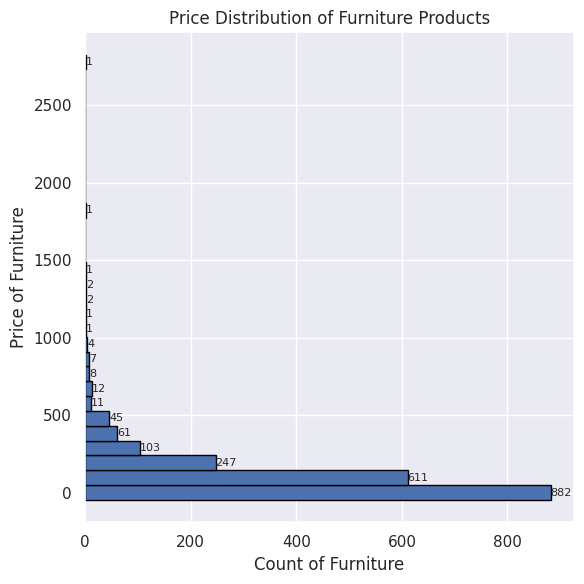

In [ ]:
plt.figure(figsize=(6,6))

# Create price bins
bins = 30
counts, bin_edges = np.histogram(df['price'], bins=bins)

# Horizontal bar chart
plt.barh(bin_edges[:-1], counts, height=np.diff(bin_edges), edgecolor='black')

plt.title("Price Distribution of Furniture Products")
plt.ylabel("Price of Furniture")
plt.xlabel("Count of Furniture")

# Add labels on bars
for y, x in zip(bin_edges[:-1], counts):
    if x > 0:   # show label only if count > 0
        plt.text(x, y, str(x), va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()


**DISTRIBUTION OF ITEMS SOLD**

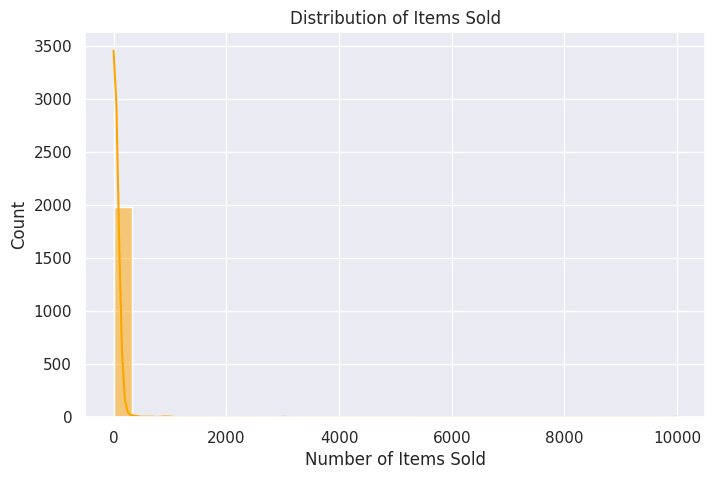

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['sold'], bins=30, kde=True, color='orange')
plt.title("Distribution of Items Sold")
plt.xlabel("Number of Items Sold")
plt.ylabel("Count")
plt.show()


**PRICE VS SOLD FURNITURE**


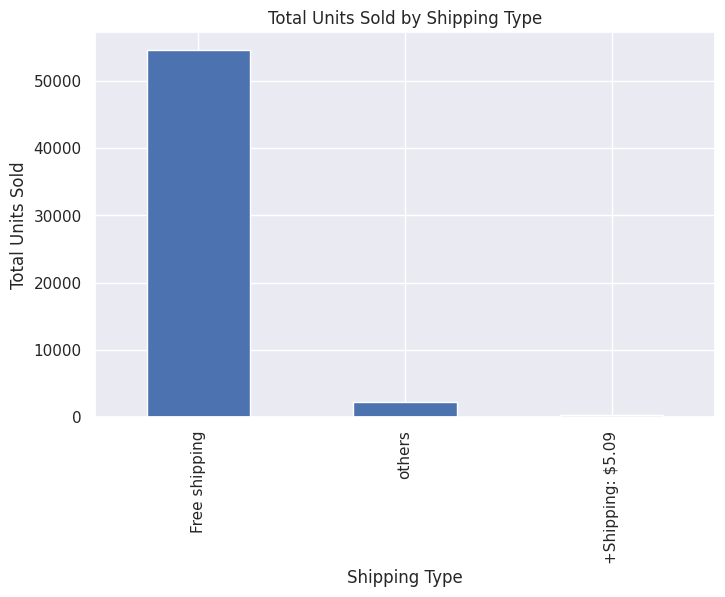

In [ ]:

totals = df.groupby('tagText')['sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
totals.plot(kind='bar')
plt.xlabel('Shipping Type')
plt.ylabel('Total Units Sold')
plt.title('Total Units Sold by Shipping Type')
plt.show()

**SHIPPING OPTION DISTRIBUTION**

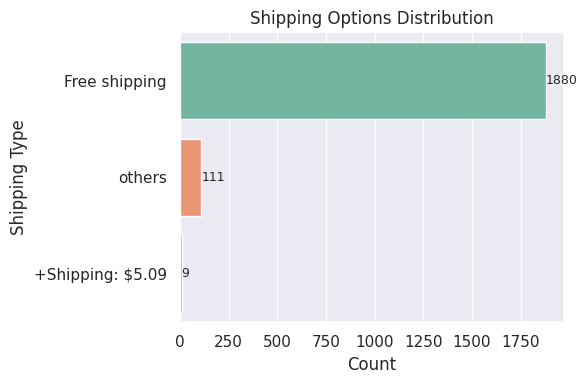

In [ ]:
plt.figure(figsize=(6, 4))

# Horizontal count plot
ax = sns.countplot(y='tagText', data=df, palette='Set2')

plt.title("Shipping Options Distribution")
plt.xlabel("Count")
plt.ylabel("Shipping Type")

# Add labels to bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()


**FEATURE ENGINEERING**

In [ ]:
# Ensure price columns are numeric before calculating discount_percentage
df['price'] = df['price'].replace('[$,]', '', regex=True).astype(float)
df['originalPrice'] = df['originalPrice'].replace('[$,]', '', regex=True).astype(float)

df['discount_percentage'] = ((df['originalPrice'] - df['price']) / df['originalPrice']) * 100

# Initialize TfidfVectorizer outside the conditional block to ensure it's always defined
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=100)

# Check if 'productTitle' column exists before processing with TF-IDF
if 'productTitle' in df.columns:
    title_features = tfidf.fit_transform(df['productTitle'].astype(str))
    title_df = pd.DataFrame(title_features.toarray(), columns=tfidf.get_feature_names_out())
    df = pd.concat([df, title_df], axis=1)
    df.drop(['productTitle'], axis=1, inplace=True)
    print("TFIDF features added and 'productTitle' dropped.")
else:
    print("Warning: 'productTitle' column not found. Skipping TFIDF feature extraction.")

# Ensure 'productTitle' is definitely removed if it somehow still exists at this point
if 'productTitle' in df.columns:
    df.drop(['productTitle'], axis=1, inplace=True)
    print("Safeguard: Explicitly dropped 'productTitle' column.")

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['tagText'] = le.fit_transform(df['tagText'])

print("\n Feature Engineering Completed!")
print(df.head(3))

TFIDF features added and 'productTitle' dropped.

 Feature Engineering Completed!
   originalPrice   price  sold  tagText  discount_percentage  adjustable  and  \
0           30.0   46.79   600       99           -55.966667         0.0  0.0   
1          116.0  169.72     9       99           -46.310345         0.0  0.0   
2           78.4   39.46     7       99            49.668367         0.0  0.0   

   bed   bedroom  bedside  ...   up  upholstered  vanity  velvet  wardrobe  \
0  0.0  0.189721      0.0  ...  0.0          0.0     0.0     0.0  0.300611   
1  0.0  0.000000      0.0  ...  0.0          0.0     0.0     0.0  0.000000   
2  0.0  0.200469      0.0  ...  0.0          0.0     0.0     0.0  0.000000   

   white    wicker      with  wood  wooden  
0    0.0  0.000000  0.120182   0.0     0.0  
1    0.0  0.300086  0.000000   0.0     0.0  
2    0.0  0.000000  0.126991   0.0     0.0  

[3 rows x 105 columns]


**MODEL TRAINING RPEDICT NUMBER OF ITMES SOLD**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Handle NaN and infinite values before splitting the data
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df = df.reset_index(drop=True) # Reset index after dropping rows

X = df.drop('sold', axis=1)
y = df['sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

**MODEL EVALUTION**

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n📈 MODEL PERFORMANCE:")
print(f"Linear Regression → MSE: {mse_lr:.2f}, R²: {r2_lr:.3f}")
print(f"Random Forest → MSE: {mse_rf:.2f}, R²: {r2_rf:.3f}")



📈 MODEL PERFORMANCE:
Linear Regression → MSE: 1108199.66, R²: -0.208
Random Forest → MSE: 935688.42, R²: -0.020


**KEY INSIGHT**

In [ ]:
print("\n📊 INSIGHTS:")
print(f"1️⃣ Total Products: {len(df)}")
print(f"2️⃣ Average Price: ${df['price'].mean():.2f}")
print(f"3️⃣ Average Discount: {df['discount_percentage'].mean():.2f}%")


if not df['tagText'].empty:
    most_common = df['tagText'].mode()[0]
    print(f"4️⃣ Most Common Shipping Type: {most_common}")
else:
    print("4️⃣ Most Common Shipping Type: N/A")


📊 INSIGHTS:
1️⃣ Total Products: 538
2️⃣ Average Price: $136.75
3️⃣ Average Discount: -5428.00%
4️⃣ Most Common Shipping Type: 99
